# Generación masiva condicionada al último estado de mercado

Este notebook es la vista reproducible de la aplicación común. Calcula la condición con las últimas 240 velas completas del panel, genera por lotes con CVAE, flow y GAN y aplica la misma cartera 60/40. La implementación vive en `src/` y en el script de ejecución para no mantener una segunda versión de la lógica dentro del notebook.

In [1]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
import json

ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
OUTPUT_DIR = ROOT / 'outputs/latest_market_scenarios'
N_SCENARIOS = 100_000
BATCH_SIZE = 1_000
SEED = 20_260_823
RUN_GENERATION = False  # Cambiar a True solo para regenerar los artefactos.
print('Raíz:', ROOT.name)


Raíz: Taller_Generativos


## 1. Ejecución controlada

La generación ocupa unos 92 MB por modelo. Por defecto se reutiliza la ejecución guardada; activar `RUN_GENERATION` vuelve a crear las 300.000 trayectorias con semillas registradas.

In [2]:
command = [
    sys.executable, str(ROOT / 'scripts/generate_latest_market_scenarios.py'),
    '--n-scenarios', str(N_SCENARIOS),
    '--batch-size', str(BATCH_SIZE),
    '--seed', str(SEED),
]
if RUN_GENERATION:
    subprocess.run(command, cwd=ROOT, check=True)
else:
    required = [OUTPUT_DIR / 'metadata.json', OUTPUT_DIR / 'portfolio_stress_report.json']
    missing = [path for path in required if not path.exists()]
    if missing:
        raise FileNotFoundError(f'Faltan artefactos; activa RUN_GENERATION: {missing}')
    print('Reutilizando la generación masiva guardada en', OUTPUT_DIR.relative_to(ROOT))


Reutilizando la generación masiva guardada en outputs/latest_market_scenarios


## 2. Estado condicionado

No se reutiliza la última condición de test: esa fila queda treinta días por detrás del final del panel porque necesita un objetivo futuro observado. Aquí se calcula una condición nueva al final del último bloque completo. La fecha se muestra explícitamente; «último» significa último dato del panel, no una consulta de mercado en vivo.

In [3]:
metadata = json.loads((OUTPUT_DIR / 'metadata.json').read_text(encoding='utf-8'))
condition = metadata['condition']
condition_summary = pd.DataFrame([
    ('inicio de condición', condition['condition_start_utc']),
    ('fin de condición', condition['condition_end_utc']),
    ('inicio de simulación', condition['forecast_start_utc']),
    ('fin exclusivo de simulación', condition['forecast_end_exclusive_utc']),
    ('precio inicial BTC', condition['initial_prices']['BTC']),
    ('precio inicial ETH', condition['initial_prices']['ETH']),
    ('máximo |z| de condición', condition['maximum_absolute_normalized_feature']),
], columns=['elemento', 'valor'])
display(condition_summary)
print('Fuera de ±5 desviaciones de train:', condition['outside_five_training_standard_deviations'])


,elemento,valor
0,inicio de condición,2026-06-01T06:00:00Z
1,fin de condición,2026-07-31T00:00:00Z
2,inicio de simulación,2026-07-31T06:00:00Z
3,fin exclusivo de simulación,2026-08-30T06:00:00Z
4,precio inicial BTC,64363.06
5,precio inicial ETH,1906.13
6,máximo |z| de condición,1.227311


Fuera de ±5 desviaciones de train: False


## 3. Riesgo de la cartera bajo el estado actual del panel

Cada modelo aporta 100.000 trayectorias de 120 pasos de seis horas. Son draws condicionados al modelo y al mismo vector de mercado; no son 100.000 historias económicas independientes.

In [4]:
summary = pd.read_csv(OUTPUT_DIR / 'scenario_summary.csv')
risk = pd.read_csv(OUTPUT_DIR / 'risk_comparison.csv')
display(summary[[
    'scenario_set', 'scenario_count', 'mean_final_loss_fraction',
    'q95_final_loss_fraction', 'q95_maximum_drawdown',
    'worst_final_loss_fraction',
]])
display(risk[[
    'scenario_set', 'confidence_level', 'value_at_risk_fraction',
    'expected_shortfall_fraction',
]])


,scenario_set,scenario_count,mean_final_loss_fraction,q95_final_loss_fraction,q95_maximum_drawdown,worst_final_loss_fraction
0,cvae,100000,-0.039847,0.142957,0.199018,0.449337
1,normalizing_flow,100000,-0.041864,0.185022,0.243291,0.633283
2,conditional_gan,100000,-0.134916,0.166881,0.316924,0.627775


,scenario_set,confidence_level,value_at_risk_fraction,expected_shortfall_fraction
0,cvae,0.95,0.142957,0.186845
1,cvae,0.99,0.214655,0.250655
2,normalizing_flow,0.95,0.185022,0.242573
3,normalizing_flow,0.99,0.279020,0.327456
4,conditional_gan,0.95,0.166881,0.264553
5,conditional_gan,0.99,0.327082,0.392643


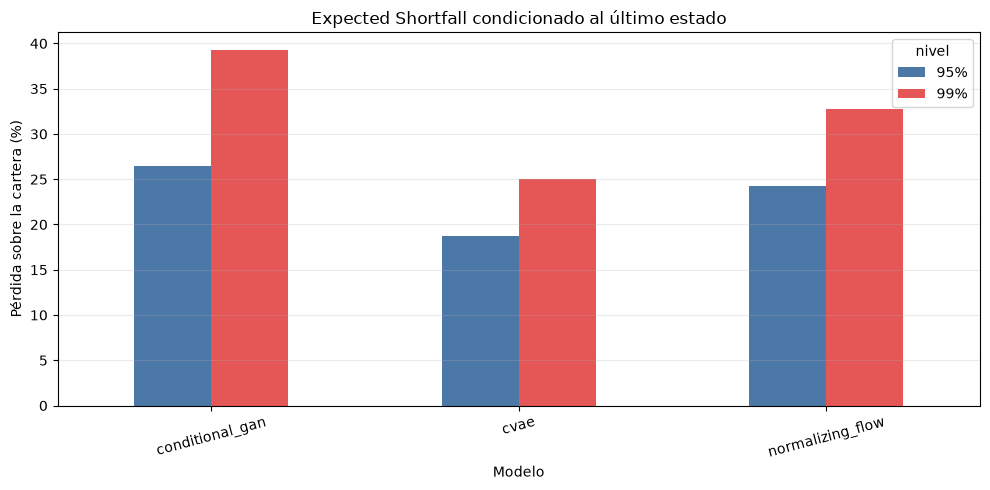

In [5]:
plot_data = risk.copy()
plot_data['nivel'] = plot_data['confidence_level'].map(lambda value: f'{value:.0%}')
pivot = plot_data.pivot(index='scenario_set', columns='nivel', values='expected_shortfall_fraction') * 100
ax = pivot.plot.bar(figsize=(10, 5), color=['#4C78A8', '#E45756'])
ax.set(title='Expected Shortfall condicionado al último estado', ylabel='Pérdida sobre la cartera (%)', xlabel='Modelo')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


## 4. Interpretación

La simulación masiva reduce el ruido de Monte Carlo y permite leer mejor el 1 % de cola que los 20 draws por condición usados durante la evaluación. No corrige, sin embargo, el error de especificación: las diferencias entre modelos deben conservarse como incertidumbre de modelo. En particular, una media favorable no invalida una cola severa ni demuestra calibración.

In [6]:
risk_99 = risk[risk['confidence_level'] == 0.99].sort_values('expected_shortfall_fraction')
least = risk_99.iloc[0]
most = risk_99.iloc[-1]
print(
    f"ES 99 % menos severo: {least['scenario_set']} ({least['expected_shortfall_fraction']:.1%})."
)
print(
    f"ES 99 % más severo: {most['scenario_set']} ({most['expected_shortfall_fraction']:.1%})."
)
print('La separación entre ambos es incertidumbre de modelo, no precisión adicional por generar más draws.')


ES 99 % menos severo: cvae (25.1%).
ES 99 % más severo: conditional_gan (39.3%).
La separación entre ambos es incertidumbre de modelo, no precisión adicional por generar más draws.
